## Importing the libraries

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import json

## Importing the dataset

In [2]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [3]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df["Sales"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Training

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

param_grid = {
    'elasticnet__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

lm = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lm.fit(X_train, y_train)
print('Meilleurs paramètres:', lm.best_params_)
best_model = lm.best_estimator_

Meilleurs paramètres: {'elasticnet__alpha': 0.001, 'elasticnet__l1_ratio': 0.9}


In [5]:
print('Meilleurs paramètres: \n', lm.best_params_)
print('Coefficients ElasticNet: \n', best_model.named_steps['elasticnet'].coef_)

Meilleurs paramètres: 
 {'elasticnet__alpha': 0.001, 'elasticnet__l1_ratio': 0.9}
Coefficients ElasticNet: 
 [ 9.27455965e+01  9.67053213e-02  1.54408668e-02 -3.03661958e-02]


## Prédiction

Text(0, 0.5, 'Predicted Y')

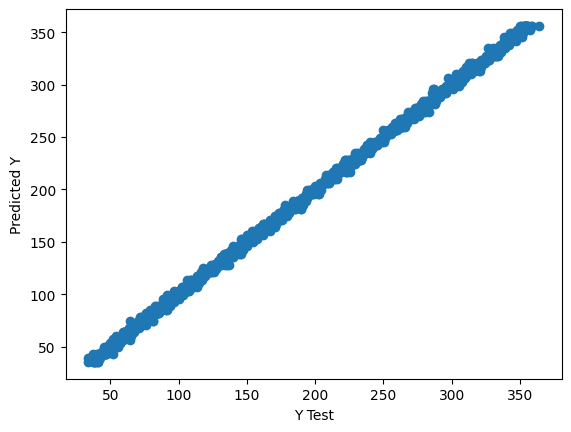

In [6]:
predictions = best_model.predict(X_test)
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [11]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")
with open('../saved_models/elasticnet_regression/metrics.json', 'w') as f:
    f.write(json.dumps({"MAE":MAE, "MSE":MSE, "RMSE":RMSE, "R2":R2}))

MAE : 2.387170913431238
MSE : 8.976500204709765
RMSE : 2.996080807439907
R2 : 0.9989705442832496



## Export model

In [8]:
import pickle

# Sauvegarder le Pipeline complet (scaler + elasticnet) pour l'inférence en production
with open('../saved_models/elasticnet_regression/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)